AFFAN NADEEM | DATA SCIENTIST
---------------------------------
### EDA REPORT

Student Performance Analysis
---------------------------------
##### Date: [20 of Oct - 2025]

#### Tools: `Python` | `Pandas` | `Matplotlib` | `Seaborn` | `Scikit-learn`


# 🧠 Objective
I wanted to explore what factors affect student academic performance and build a predictive model that estimates final grades based on personal, social, and study-related variables. This project combines exploratory data analysis (EDA) and machine learning to uncover insights that can help educators and students improve outcomes.



# 🧹 Data Cleaning
I began by loading the dataset and checking for missing or inconsistent data. I handled null values, encoded categorical variables, standardized numerical columns, and ensured all data types were correct. Columns were renamed for readability, and unnecessary features were dropped to streamline the analysis.



# 🔍 Exploratory Data Analysis (EDA)
I explored how different features — such as study time, parental education, gender, and test preparation — relate to students' math, reading, and writing scores. Using visual analysis, I identified patterns, correlations, and distributions that reveal how each factor impacts performance.



# 📈 Visualizations
- Distribution of math, reading, and writing scores  
- Correlation heatmap to identify strong relationships between features  
- Score comparison by gender and parental education level  
- Effect of test preparation course on overall performance  
- Study time vs. total score scatter plot  



# 🧰 Tools Used
`Python` | `Pandas` | `NumPy` | `Matplotlib` | `Seaborn` | `Scikit-learn` | `Jupyter Notebook`


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import os 




In [3]:

df=pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
# checking missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# adding a column of online and offline
df["study_mode"] = np.random.choice(["online", "offline"],size=len(df))
df["study_mode"]

0      offline
1       online
2      offline
3      offline
4       online
        ...   
995     online
996    offline
997     online
998    offline
999    offline
Name: study_mode, Length: 1000, dtype: object

In [ ]:
categorical_cols = [df.select_dtypes(include=['object']).columns]
for col in categorical_cols:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")



In [6]:
# Adding a column for average_score = (Math + Reading + Writing) / 3.
df["average_score"] = (df["math score"]+ df["reading score"]+ df["writing score"])/3
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,offline,72.666667
1,female,group C,some college,standard,completed,69,90,88,online,82.333333
2,female,group B,master's degree,standard,none,90,95,93,offline,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,offline,49.333333
4,male,group C,some college,standard,none,76,78,75,online,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,online,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,offline,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,online,65.000000
998,female,group D,some college,standard,completed,68,78,77,offline,74.333333


In [7]:
# Categorize performance
def performance_category(score):
    if score >= 80:
        return "A"
    elif score >= 60:
        return "Average"
    else:
        return "Low"

df["Performance"] = df["average_score"].apply(performance_category)
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score,Performance
0,female,group B,bachelor's degree,standard,none,72,72,74,offline,72.666667,Average
1,female,group C,some college,standard,completed,69,90,88,online,82.333333,A
2,female,group B,master's degree,standard,none,90,95,93,offline,92.666667,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,offline,49.333333,Low
4,male,group C,some college,standard,none,76,78,75,online,76.333333,Average
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,online,94.000000,A
996,male,group C,high school,free/reduced,none,62,55,55,offline,57.333333,Low
997,female,group C,high school,free/reduced,completed,59,71,65,online,65.000000,Average
998,female,group D,some college,standard,completed,68,78,77,offline,74.333333,Average


In [8]:
df['grade'] = pd.cut(df['average_score'],
                     bins=[0, 50, 65, 80, 100],
                     labels=['Fail', 'Average', 'Good', 'Excellent'])
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score,Performance,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,offline,72.666667,Average,Good
1,female,group C,some college,standard,completed,69,90,88,online,82.333333,A,Excellent
2,female,group B,master's degree,standard,none,90,95,93,offline,92.666667,A,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,offline,49.333333,Low,Fail
4,male,group C,some college,standard,none,76,78,75,online,76.333333,Average,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,online,94.000000,A,Excellent
996,male,group C,high school,free/reduced,none,62,55,55,offline,57.333333,Low,Average
997,female,group C,high school,free/reduced,completed,59,71,65,online,65.000000,Average,Average
998,female,group D,some college,standard,completed,68,78,77,offline,74.333333,Average,Good


In [9]:
#  handling Categorical feature gender and study mode 1 for Male 2 for female 
#  1 for online study mode and 2 for offline study mode
df["gender"].nunique()
df["gender"] = df["gender"].map({"male":1,"female":0})

df["study_mode"] = df["study_mode"].map({"online":1,"offline":2})
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score,Performance,grade
0,0,group B,bachelor's degree,standard,none,72,72,74,2,72.666667,Average,Good
1,0,group C,some college,standard,completed,69,90,88,1,82.333333,A,Excellent
2,0,group B,master's degree,standard,none,90,95,93,2,92.666667,A,Excellent
3,1,group A,associate's degree,free/reduced,none,47,57,44,2,49.333333,Low,Fail
4,1,group C,some college,standard,none,76,78,75,1,76.333333,Average,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,group E,master's degree,standard,completed,88,99,95,1,94.000000,A,Excellent
996,1,group C,high school,free/reduced,none,62,55,55,2,57.333333,Low,Average
997,0,group C,high school,free/reduced,completed,59,71,65,1,65.000000,Average,Average
998,0,group D,some college,standard,completed,68,78,77,2,74.333333,Average,Good


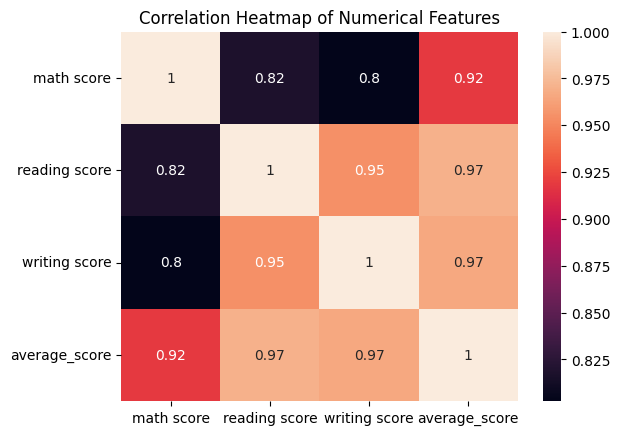

In [10]:
# correlation heatmap between numeric features
num = df[["math score","reading score","writing score","average_score"]]
numric_feature = num 
corr = numric_feature.corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap of Numerical Features')
#plt.savefig("images/Correlation_Heatmap_of_Numerical_Features.png", dpi=300, bbox_inches='tight')
plt.show()

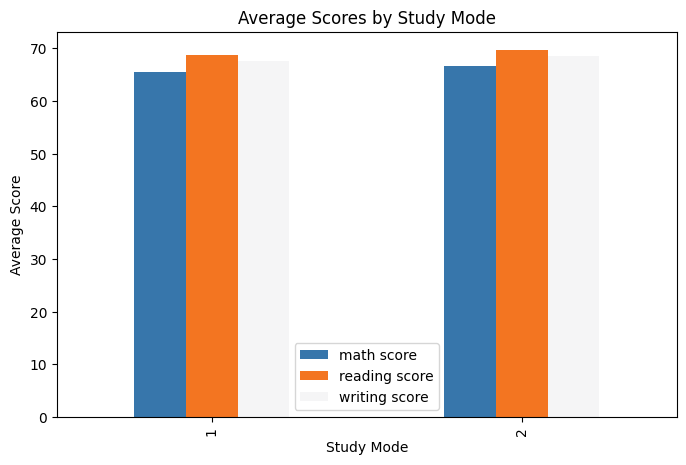

In [11]:
avg_by_study_mode = df.groupby(["study_mode"])[["math score","reading score","writing score"]].mean()

# Visualization
avg_by_study_mode.plot(kind='bar', figsize=(8,5),color=["#3776ab","#f37521","#f5f5f6"])
plt.title("Average Scores by Study Mode")
plt.ylabel("Average Score")
plt.xlabel("Study Mode")
#plt.savefig("images/Average_Scores_by_Study_Mode.png", dpi=300, bbox_inches='tight')
plt.show()

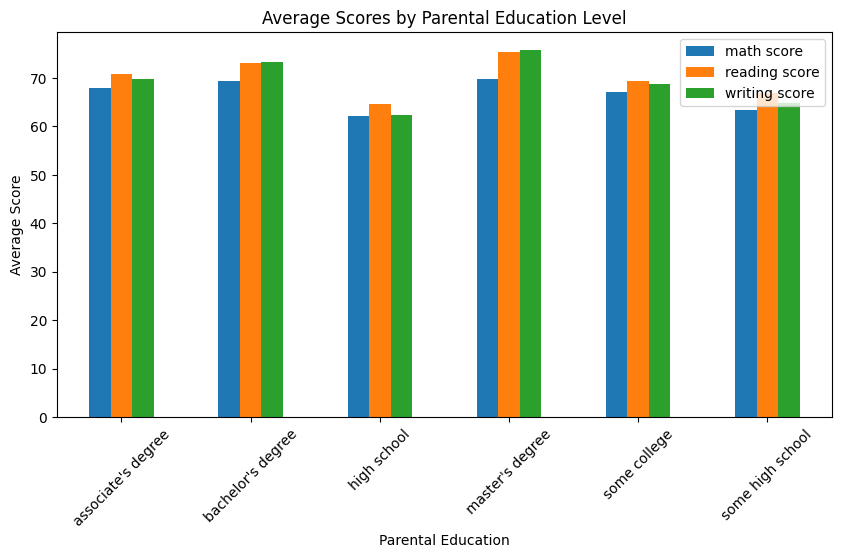

In [12]:
# Average scores by parental education
parent_edu = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()

parent_edu.plot(kind='bar', figsize=(10,5))
plt.title("Average Scores by Parental Education Level")
plt.ylabel("Average Score")
plt.xlabel("Parental Education")
plt.xticks(rotation=45)
#plt.savefig("images/Average_Scores_by_Parental_Education_Level.png", dpi=300, bbox_inches='tight')
plt.show()



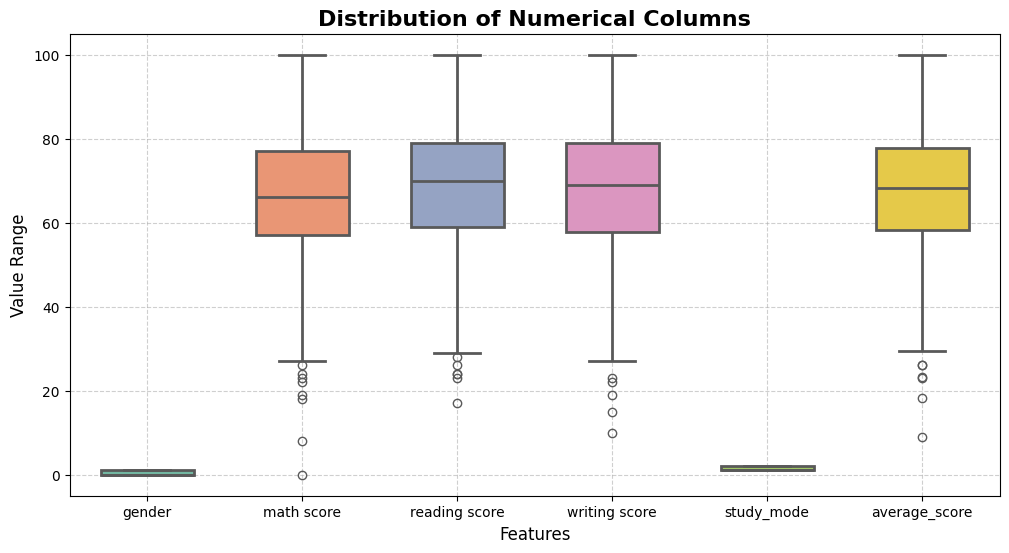

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, palette="Set2", width=0.6, linewidth=2)
plt.title("Distribution of Numerical Columns", fontsize=16, weight='bold')
plt.xlabel("Features", fontsize=12)
plt.ylabel("Value Range", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
#plt.savefig("images/Distribution_of_Numerical_Columns.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11084\2154378294.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test preparation course', y='average_score', data=df, palette="coolwarm")


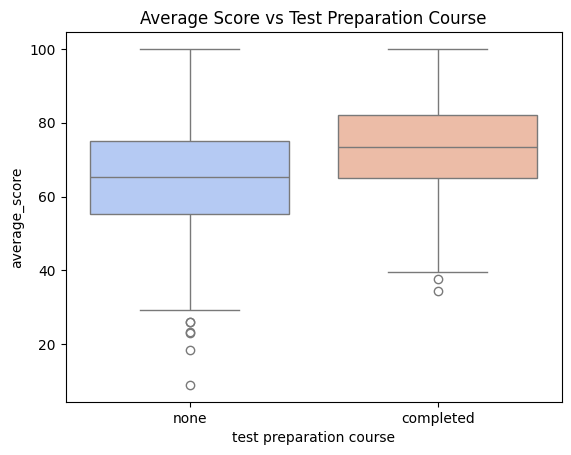

In [14]:

# Test preparation impact
sns.boxplot(x='test preparation course', y='average_score', data=df, palette="coolwarm")
plt.title("Average Score vs Test Preparation Course")
#plt.savefig("images/Average_Score_vs_Test_Preparation_Course.png", dpi=300, bbox_inches='tight')
plt.show()

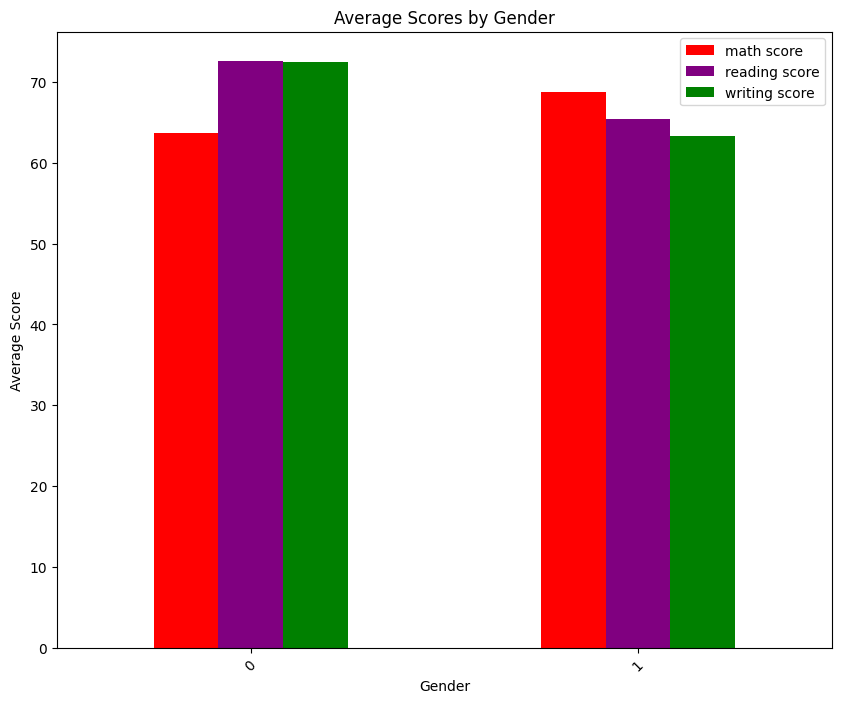

In [15]:
performance_by_gender = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
performance_by_gender.plot(kind="bar",figsize=(10,8) ,color=["red","purple","green"])
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.xlabel("Gender")
plt.xticks(rotation=45)
#plt.savefig("images/Average_Scores_by_Gender.png", dpi=300, bbox_inches='tight')
plt.show()


In [16]:
# Using IQR for average score
Q1 = df['average_score'].quantile(0.25)
Q3 = df['average_score'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['average_score'] < (Q1 - 1.5*IQR)) | (df['average_score'] > (Q3 + 1.5*IQR))]
print(f"Number of average scores outliers: {len(outliers)}")


Number of average scores outliers: 6


<Axes: ylabel='average_score'>

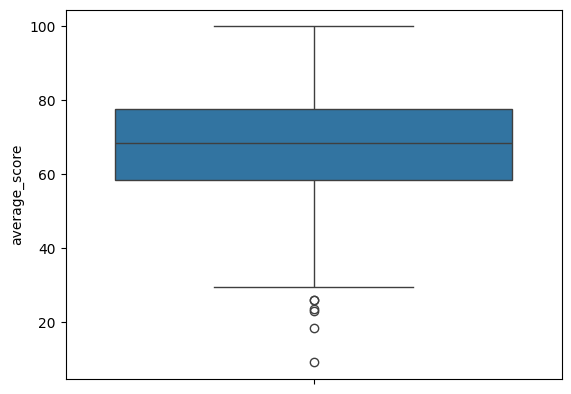

In [17]:
sns.boxplot(df["average_score"])

In [18]:

#features  most associated with high performance.
corrs = df.corr(numeric_only=True)['average_score'].sort_values(ascending=False)
print(corrs)

average_score    1.000000
reading score    0.970331
writing score    0.965667
math score       0.918746
study_mode       0.033587
gender          -0.130861
Name: average_score, dtype: float64


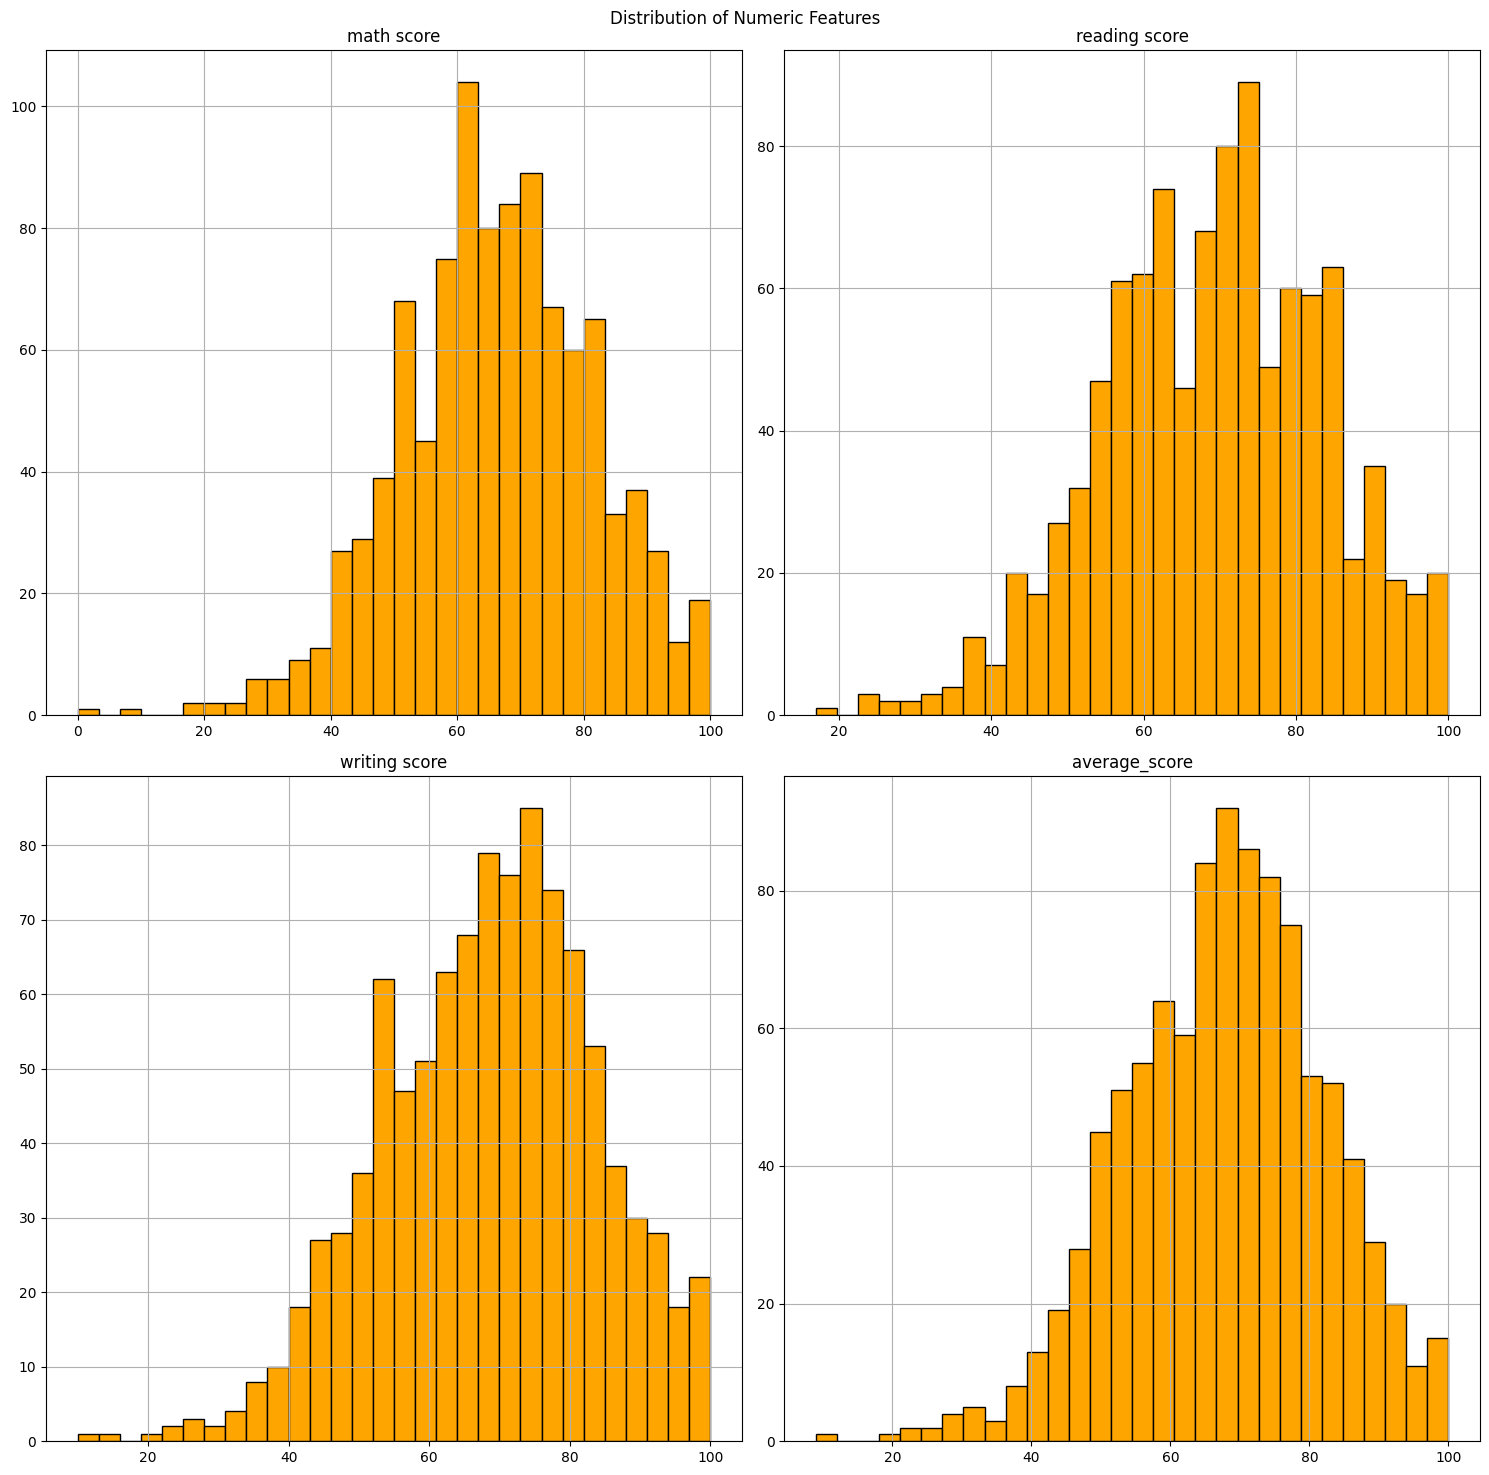

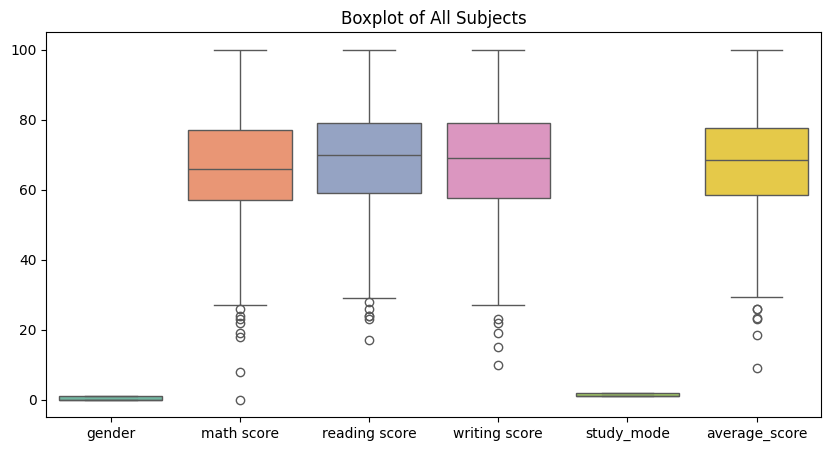

In [19]:
df.drop(["gender","study_mode"],axis=1).hist(color="orange",figsize=(15,15),bins=30,edgecolor='black')
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.savefig("images/Distribution_of_Numeric_Features.png", dpi=300, bbox_inches='tight')
plt.show()


plt.show()

# Boxplots for outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df, palette="Set2")
plt.title("Boxplot of All Subjects")
plt.show()


In [20]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_mode,average_score,Performance,grade
0,0,group B,bachelor's degree,standard,none,72,72,74,2,72.666667,Average,Good
1,0,group C,some college,standard,completed,69,90,88,1,82.333333,A,Excellent
2,0,group B,master's degree,standard,none,90,95,93,2,92.666667,A,Excellent
3,1,group A,associate's degree,free/reduced,none,47,57,44,2,49.333333,Low,Fail
4,1,group C,some college,standard,none,76,78,75,1,76.333333,Average,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,group E,master's degree,standard,completed,88,99,95,1,94.000000,A,Excellent
996,1,group C,high school,free/reduced,none,62,55,55,2,57.333333,Low,Average
997,0,group C,high school,free/reduced,completed,59,71,65,1,65.000000,Average,Average
998,0,group D,some college,standard,completed,68,78,77,2,74.333333,Average,Good
